EHR DATA PREPROCESSING PIPELINE (ENHANCED)

Input path: /content/drive/MyDrive/MULTIMODAL/datasets/diabetes_prediction/diabetes_prediction_dataset.csv
Output directory: /content/drive/MyDrive/MULTIMODAL/datasets/diabetes_prediction
Balancing strategy: undersample
Balance train only: True
Scaling method: standard

STEP 1: DATA LOADING

Dataset shape: (100000, 9)
Number of samples: 100,000
Number of features: 9

First 5 rows:
   gender   age  hypertension  heart_disease smoking_history    bmi  \
0  Female  80.0             0              1           never  25.19   
1  Female  54.0             0              0         No Info  27.32   
2    Male  28.0             0              0           never  27.32   
3  Female  36.0             0              0         current  23.45   
4    Male  76.0             1              1         current  20.14   

   HbA1c_level  blood_glucose_level  diabetes  
0          6.6                  140         0  
1          6.6                   80         0  
2

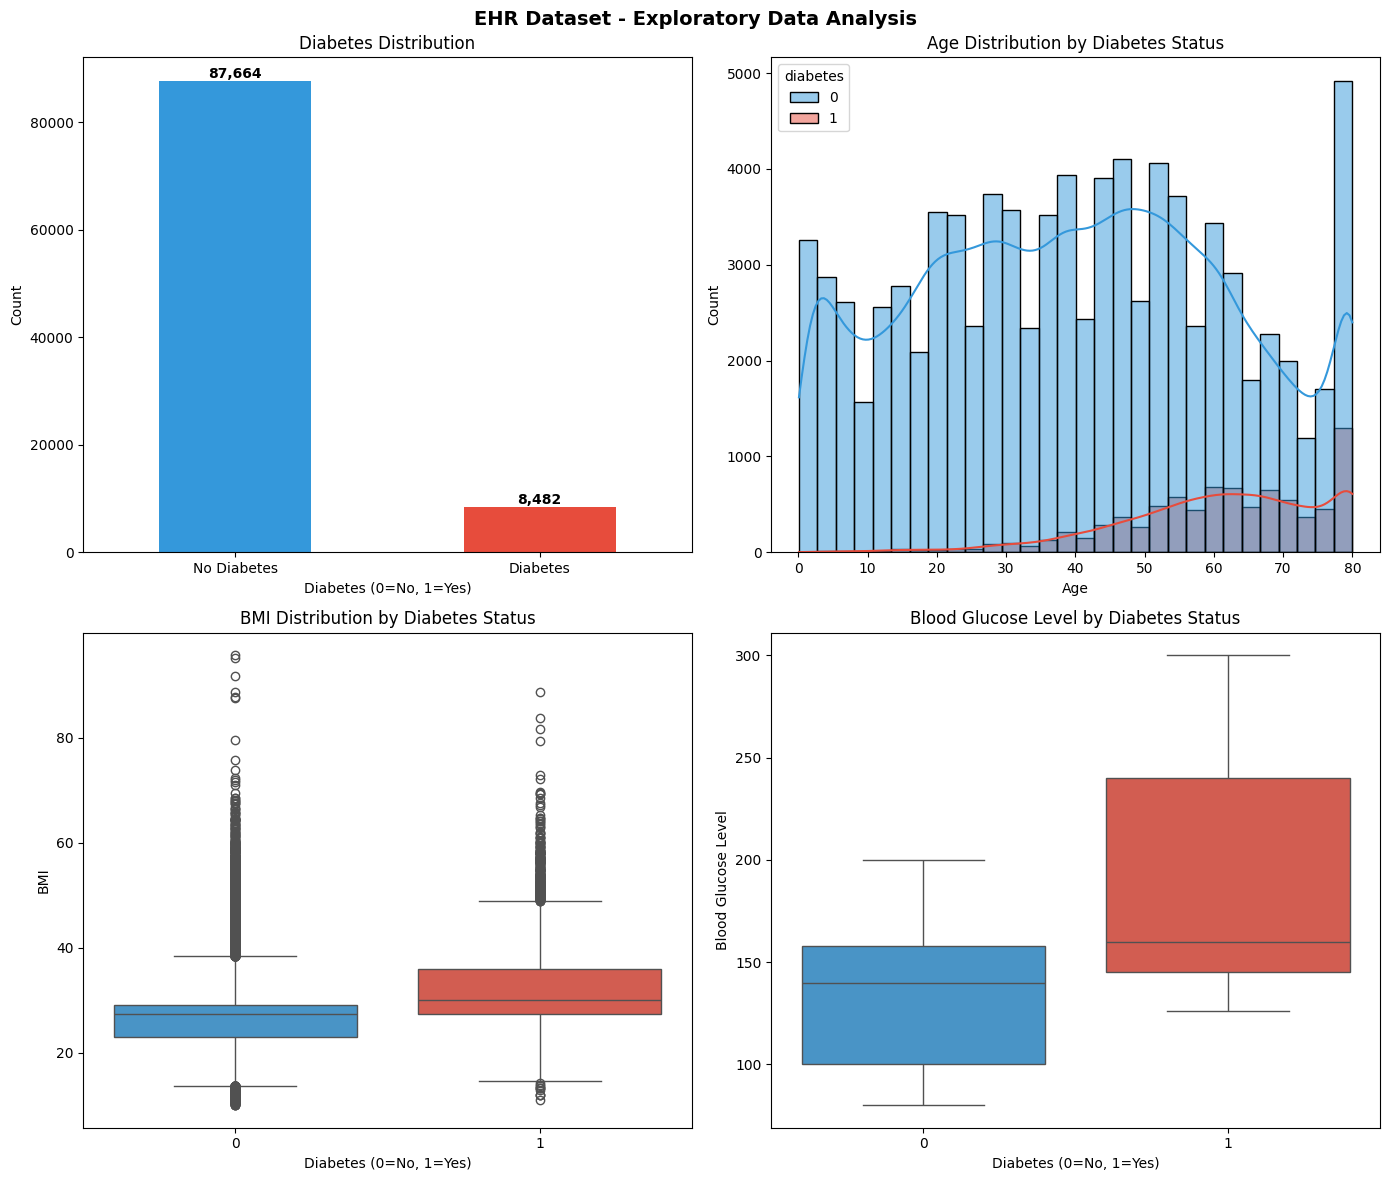

Saved: /content/drive/MyDrive/MULTIMODAL/datasets/diabetes_prediction/figures/eda_overview.png

STEP 6: FEATURE ENCODING

Categorical columns to encode: ['gender', 'smoking_history']

gender encoding:
  {'Female': 0, 'Male': 1, 'Other': 2}

smoking_history encoding:
  {'No Info': 0, 'current': 1, 'ever': 2, 'former': 3, 'never': 4, 'not current': 5}

Encoded dataset preview:
   gender   age  hypertension  heart_disease  smoking_history    bmi  \
0       0  80.0             0              1                4  25.19   
1       0  54.0             0              0                0  27.32   
2       1  28.0             0              0                4  27.32   
3       0  36.0             0              0                1  23.45   
4       1  76.0             1              1                1  20.14   

   HbA1c_level  blood_glucose_level  diabetes  
0          6.6                  140         0  
1          6.6                   80         0  
2          5.7                  158         0

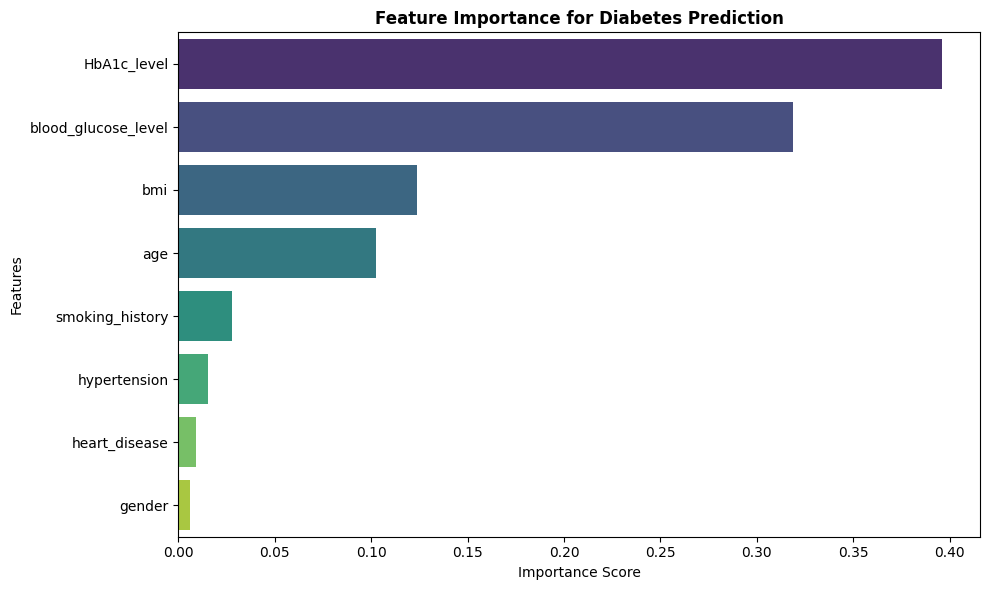

Saved: /content/drive/MyDrive/MULTIMODAL/datasets/diabetes_prediction/figures/feature_importance.png

STEP 8: CORRELATION ANALYSIS


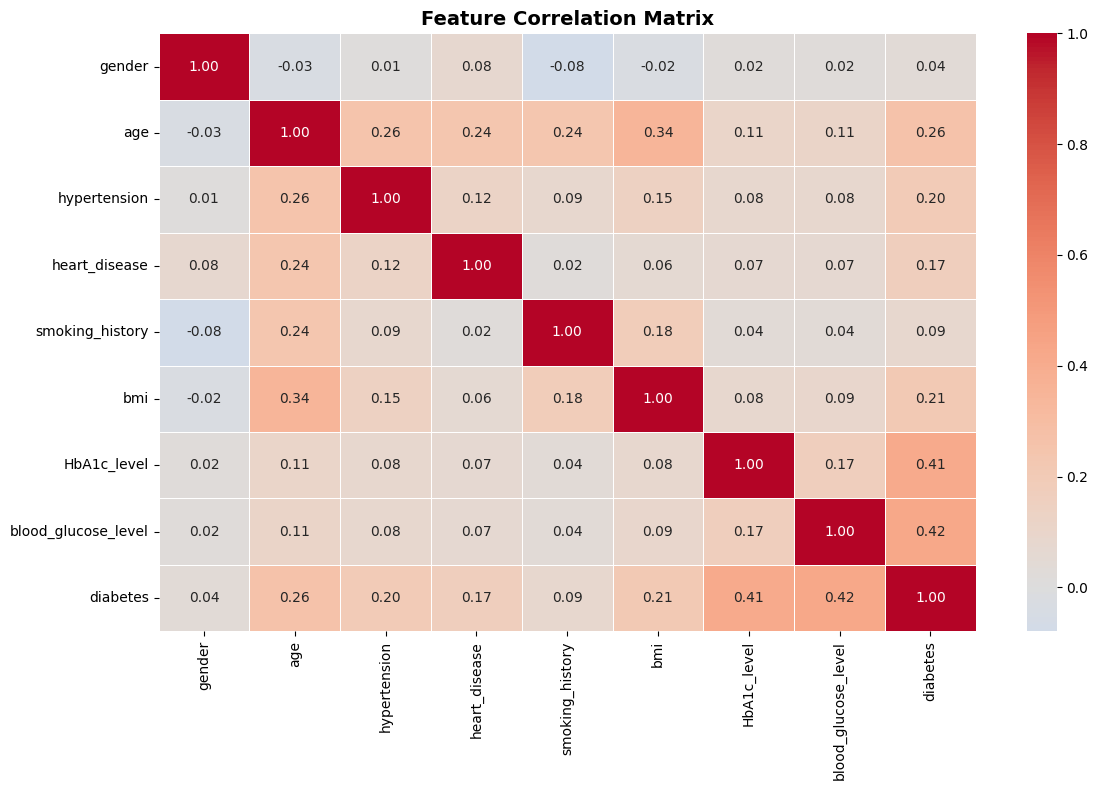

Saved: /content/drive/MyDrive/MULTIMODAL/datasets/diabetes_prediction/figures/correlation_matrix.png

STEP 9: STRATIFIED TRAIN/VAL/TEST SPLIT

Split configuration:
  Test size:  15.0%
  Val size:   15.0%
  Train size: 70.0%

Dataset sizes (before balancing):
  Training:   67,302 samples
  Validation: 14,422 samples
  Test:       14,422 samples

Class distribution in each split:
  Train - Class 0: 61,364, Class 1: 5,938 (ratio: 10.33)
  Val   - Class 0: 13,150, Class 1: 1,272 (ratio: 10.34)
  Test  - Class 0: 13,150, Class 1: 1,272 (ratio: 10.34)

STEP 10: CLASS IMBALANCE HANDLING

Balancing strategy: undersample
Balance training set only: True

Original training set distribution:
  Class 0 (No Diabetes): 61,364
  Class 1 (Diabetes):    5,938
  Imbalance ratio:       10.33

Undersampling to 5,938 samples per class...

After balancing (undersample):

Training set:
  Class 0: 5,938
  Class 1: 5,938
  Total:   11,876

Validation set (original distribution preserved):
  Class 0: 13,150
  Cl

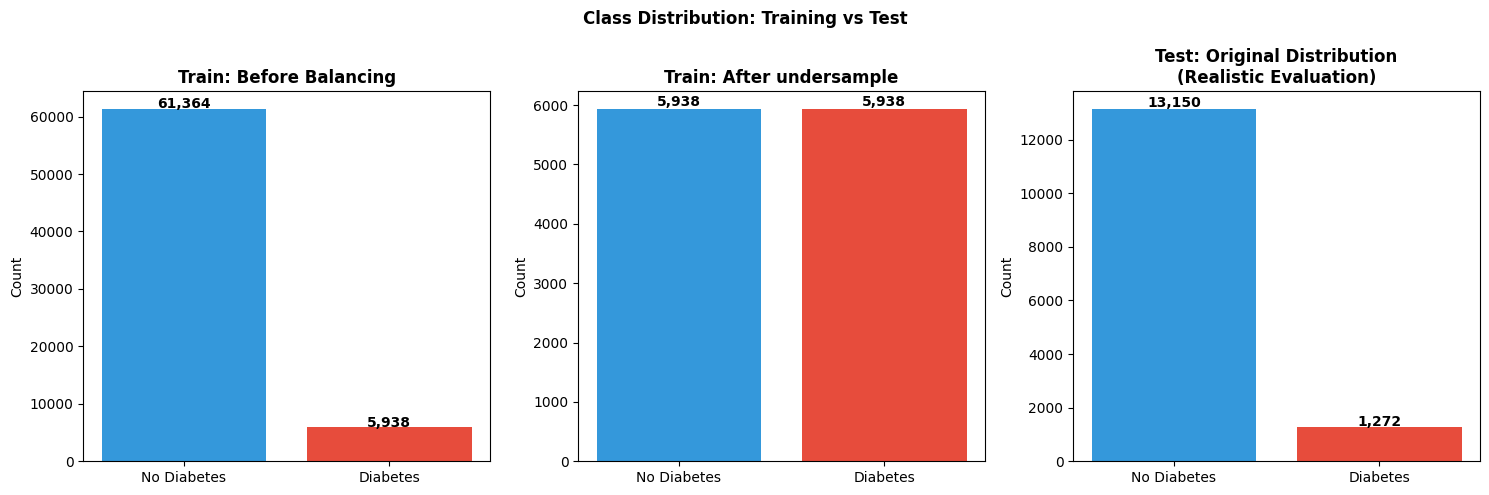

Saved: /content/drive/MyDrive/MULTIMODAL/datasets/diabetes_prediction/figures/class_balancing.png

STEP 11: FEATURE SCALING

Scaling method: standard
Continuous features to scale: ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']
Found continuous features: ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']

Fitting scaler on training data...
Transforming all datasets...

✓ Scaling applied to: ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']

Scaling parameters (fitted on training data):
            feature       mean       std
                age  50.605325 21.439845
                bmi  29.422679  7.455537
        HbA1c_level   6.166622  1.280161
blood_glucose_level 162.990485 56.548584

✓ Scaler saved to: /content/drive/MyDrive/MULTIMODAL/datasets/diabetes_prediction/ehr_scaler.pkl

STEP 12: SAVE ENCODERS AND CONFIGURATION
✓ Encoders saved to: /content/drive/MyDrive/MULTIMODAL/datasets/diabetes_prediction/ehr_encoders.json
✓ Configuration saved to: /content/drive/MyDrive/MUL

In [3]:
"""
================================================================================
EHR Data Preprocessing for Binary Diabetes Detection (ENHANCED VERSION)
================================================================================

This notebook handles:
1. Data loading and exploration
2. Missing value handling
3. Duplicate removal
4. Exploratory Data Analysis (EDA)
5. Feature encoding (categorical → numerical)
6. Feature importance analysis
7. Stratified Train/Val/Test Split (BEFORE balancing)
8. Class imbalance handling (UNDERSAMPLING - training set only)
9. Feature scaling (fit on train, apply to all)
10. Saving preprocessed datasets and artifacts

Dataset: diabetes_prediction_dataset.csv
Outputs:
  - ehr_train.csv, ehr_val.csv, ehr_test.csv
  - ehr_scaler.pkl
  - ehr_encoders.json

Author: [Your Name]
Date: 2025
Project: Multimodal Federated Learning for Diabetes Detection
================================================================================
"""

# ============================================================================
# 1. IMPORTS
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
import warnings
import os
import json
import pickle

warnings.filterwarnings("ignore")
pd.options.display.max_rows = None
pd.options.display.max_columns = None

print("=" * 70)
print("EHR DATA PREPROCESSING PIPELINE (ENHANCED)")
print("=" * 70)

# ============================================================================
# 2. CONFIGURATION
# ============================================================================

class PreprocessingConfig:
    """Configuration for preprocessing pipeline."""

    # Input/Output paths
    INPUT_PATH = "/content/drive/MyDrive/MULTIMODAL/datasets/diabetes_prediction/diabetes_prediction_dataset.csv"
    OUTPUT_DIR = "/content/drive/MyDrive/MULTIMODAL/datasets/diabetes_prediction"
    FIGURES_PATH = "/content/drive/MyDrive/MULTIMODAL/datasets/diabetes_prediction/figures"

    # Output file names
    OUTPUT_TRAIN = "ehr_train.csv"
    OUTPUT_VAL = "ehr_val.csv"
    OUTPUT_TEST = "ehr_test.csv"
    OUTPUT_FULL_BALANCED = "diabetes_prediction_balanced_processed.csv"  # Keep for backward compatibility
    OUTPUT_SCALER = "ehr_scaler.pkl"
    OUTPUT_ENCODERS = "ehr_encoders.json"
    OUTPUT_CONFIG = "ehr_preprocessing_config.json"

    # Target column
    TARGET_COLUMN = "diabetes"

    # ─────────────────────────────────────────────────────────────────
    # FEATURE CONFIGURATION
    # ─────────────────────────────────────────────────────────────────
    CONTINUOUS_FEATURES = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']
    # Categorical features will be auto-detected

    # ─────────────────────────────────────────────────────────────────
    # SPLIT CONFIGURATION
    # ─────────────────────────────────────────────────────────────────
    TEST_SIZE = 0.15        # 15% for test
    VAL_SIZE = 0.15         # 15% for validation (from remaining 85%)
    # Results in approx: 72.25% train, 12.75% val, 15% test

    # ─────────────────────────────────────────────────────────────────
    # BALANCING CONFIGURATION
    # ─────────────────────────────────────────────────────────────────
    BALANCING_STRATEGY = 'undersample'  # Options: 'undersample', 'oversample', 'smote', 'custom', 'none'
    TARGET_SAMPLES_PER_CLASS = 8000     # Used for 'custom' strategy (set to None for auto)
    BALANCE_TRAIN_ONLY = True           # If True, only balance training set (recommended)

    # ─────────────────────────────────────────────────────────────────
    # SCALING CONFIGURATION
    # ─────────────────────────────────────────────────────────────────
    SCALING_METHOD = 'standard'  # Options: 'standard', 'minmax', 'robust', 'none'

    # Random seed
    SEED = 42

config = PreprocessingConfig()

# Create directories if they don't exist
os.makedirs(config.FIGURES_PATH, exist_ok=True)
os.makedirs(config.OUTPUT_DIR, exist_ok=True)

print(f"\nInput path: {config.INPUT_PATH}")
print(f"Output directory: {config.OUTPUT_DIR}")
print(f"Balancing strategy: {config.BALANCING_STRATEGY}")
print(f"Balance train only: {config.BALANCE_TRAIN_ONLY}")
print(f"Scaling method: {config.SCALING_METHOD}")

# ============================================================================
# 3. DATA LOADING
# ============================================================================

print("\n" + "=" * 70)
print("STEP 1: DATA LOADING")
print("=" * 70)

df = pd.read_csv(config.INPUT_PATH)

print(f"\nDataset shape: {df.shape}")
print(f"Number of samples: {df.shape[0]:,}")
print(f"Number of features: {df.shape[1]}")

print("\nFirst 5 rows:")
print(df.head())

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

# ============================================================================
# 4. DATA QUALITY CHECK
# ============================================================================

print("\n" + "=" * 70)
print("STEP 2: DATA QUALITY CHECK")
print("=" * 70)

# Check for missing values
print("\nMissing values per column:")
missing_values = df.isnull().sum()
print(missing_values)
print(f"\nTotal missing values: {missing_values.sum()}")

# Check for duplicates
duplicate_count = df.duplicated().sum()
print(f"\nDuplicate rows: {duplicate_count:,}")

# Remove duplicates if any
if duplicate_count > 0:
    df_original_size = len(df)
    df = df.drop_duplicates(keep='first')
    print(f"Removed {duplicate_count:,} duplicate rows")
    print(f"New dataset size: {len(df):,}")
else:
    print("No duplicates found")

# ============================================================================
# 5. DATA SUMMARY STATISTICS
# ============================================================================

print("\n" + "=" * 70)
print("STEP 3: DATA SUMMARY STATISTICS")
print("=" * 70)

print("\nNumerical features summary:")
print(df.describe())

print("\nCategorical features:")
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns: {categorical_cols}")

for col in categorical_cols:
    print(f"\n{col} value counts:")
    print(df[col].value_counts())

# ============================================================================
# 6. TARGET VARIABLE ANALYSIS
# ============================================================================

print("\n" + "=" * 70)
print("STEP 4: TARGET VARIABLE ANALYSIS")
print("=" * 70)

target_counts = df[config.TARGET_COLUMN].value_counts()
print(f"\nTarget variable distribution ({config.TARGET_COLUMN}):")
print(target_counts)

imbalance_ratio = target_counts.iloc[0] / target_counts.iloc[1]
print(f"\nClass imbalance ratio: {imbalance_ratio:.2f}")

if imbalance_ratio > 2.0:
    print("⚠️  Dataset is IMBALANCED (ratio > 2.0)")
else:
    print("✓ Dataset is relatively balanced")

# ============================================================================
# 7. EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================================

print("\n" + "=" * 70)
print("STEP 5: EXPLORATORY DATA ANALYSIS")
print("=" * 70)

# Create EDA visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('EHR Dataset - Exploratory Data Analysis', fontsize=14, fontweight='bold')

# Plot 1: Target distribution
ax1 = axes[0, 0]
colors = ['#3498DB', '#E74C3C']
target_counts.plot(kind='bar', ax=ax1, color=colors)
ax1.set_title('Diabetes Distribution')
ax1.set_xlabel('Diabetes (0=No, 1=Yes)')
ax1.set_ylabel('Count')
ax1.set_xticklabels(['No Diabetes', 'Diabetes'], rotation=0)
for i, v in enumerate(target_counts.values):
    ax1.text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

# Plot 2: Age distribution by diabetes
ax2 = axes[0, 1]
sns.histplot(data=df, x='age', hue='diabetes', kde=True, bins=30, ax=ax2, palette=colors)
ax2.set_title('Age Distribution by Diabetes Status')
ax2.set_xlabel('Age')
ax2.set_ylabel('Count')

# Plot 3: BMI distribution by diabetes
ax3 = axes[1, 0]
sns.boxplot(data=df, x='diabetes', y='bmi', ax=ax3, palette=colors)
ax3.set_title('BMI Distribution by Diabetes Status')
ax3.set_xlabel('Diabetes (0=No, 1=Yes)')
ax3.set_ylabel('BMI')

# Plot 4: Blood glucose level by diabetes
ax4 = axes[1, 1]
sns.boxplot(data=df, x='diabetes', y='blood_glucose_level', ax=ax4, palette=colors)
ax4.set_title('Blood Glucose Level by Diabetes Status')
ax4.set_xlabel('Diabetes (0=No, 1=Yes)')
ax4.set_ylabel('Blood Glucose Level')

plt.tight_layout()
plt.savefig(f"{config.FIGURES_PATH}/eda_overview.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {config.FIGURES_PATH}/eda_overview.png")

# ============================================================================
# 8. FEATURE ENCODING
# ============================================================================

print("\n" + "=" * 70)
print("STEP 6: FEATURE ENCODING")
print("=" * 70)

# Identify categorical columns
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()
print(f"\nCategorical columns to encode: {categorical_columns}")

# Store encoding mappings for documentation
encoding_mappings = {}
label_encoders = {}  # Store encoder objects for later use

# Apply Label Encoding
for column in categorical_columns:
    label_encoder = LabelEncoder()
    df[column] = label_encoder.fit_transform(df[column])
    label_encoders[column] = label_encoder
    encoding_mappings[column] = {str(k): int(v) for k, v in
                                  zip(label_encoder.classes_,
                                      label_encoder.transform(label_encoder.classes_))}
    print(f"\n{column} encoding:")
    print(f"  {encoding_mappings[column]}")

print("\nEncoded dataset preview:")
print(df.head())

# ============================================================================
# 9. FEATURE IMPORTANCE ANALYSIS
# ============================================================================

print("\n" + "=" * 70)
print("STEP 7: FEATURE IMPORTANCE ANALYSIS")
print("=" * 70)

# Prepare features and target
X = df.drop(config.TARGET_COLUMN, axis=1)
y = df[config.TARGET_COLUMN]

print(f"\nFeatures: {X.columns.tolist()}")
print(f"Number of features: {X.shape[1]}")

# Train Random Forest to get feature importance
rf_model = RandomForestClassifier(n_estimators=100, random_state=config.SEED)
rf_model.fit(X, y)

# Get feature importance
importance_scores = rf_model.feature_importances_
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': importance_scores
}).sort_values('importance', ascending=False)

print("\nFeature Importance Ranking:")
print(feature_importance.to_string(index=False))

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='importance', y='feature', palette='viridis')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.title('Feature Importance for Diabetes Prediction', fontweight='bold')
plt.tight_layout()
plt.savefig(f"{config.FIGURES_PATH}/feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {config.FIGURES_PATH}/feature_importance.png")

# ============================================================================
# 10. CORRELATION ANALYSIS
# ============================================================================

print("\n" + "=" * 70)
print("STEP 8: CORRELATION ANALYSIS")
print("=" * 70)

# Calculate correlation matrix
correlation_matrix = df.corr()

# Plot correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{config.FIGURES_PATH}/correlation_matrix.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {config.FIGURES_PATH}/correlation_matrix.png")

# ============================================================================
# 11. STRATIFIED TRAIN/VAL/TEST SPLIT (BEFORE BALANCING)
# ============================================================================

print("\n" + "=" * 70)
print("STEP 9: STRATIFIED TRAIN/VAL/TEST SPLIT")
print("=" * 70)

# First split: separate test set
X = df.drop(config.TARGET_COLUMN, axis=1)
y = df[config.TARGET_COLUMN]

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=config.TEST_SIZE,
    stratify=y,
    random_state=config.SEED
)

# Second split: separate train and validation from remaining data
# Adjust val_size to account for the reduced dataset
val_size_adjusted = config.VAL_SIZE / (1 - config.TEST_SIZE)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=val_size_adjusted,
    stratify=y_temp,
    random_state=config.SEED
)

print(f"\nSplit configuration:")
print(f"  Test size:  {config.TEST_SIZE * 100:.1f}%")
print(f"  Val size:   {config.VAL_SIZE * 100:.1f}%")
print(f"  Train size: {(1 - config.TEST_SIZE - config.VAL_SIZE) * 100:.1f}%")

print(f"\nDataset sizes (before balancing):")
print(f"  Training:   {len(X_train):,} samples")
print(f"  Validation: {len(X_val):,} samples")
print(f"  Test:       {len(X_test):,} samples")

print(f"\nClass distribution in each split:")
print(f"  Train - Class 0: {sum(y_train == 0):,}, Class 1: {sum(y_train == 1):,} (ratio: {sum(y_train == 0)/sum(y_train == 1):.2f})")
print(f"  Val   - Class 0: {sum(y_val == 0):,}, Class 1: {sum(y_val == 1):,} (ratio: {sum(y_val == 0)/sum(y_val == 1):.2f})")
print(f"  Test  - Class 0: {sum(y_test == 0):,}, Class 1: {sum(y_test == 1):,} (ratio: {sum(y_test == 0)/sum(y_test == 1):.2f})")

# Reconstruct DataFrames
df_train = pd.concat([X_train, y_train], axis=1).reset_index(drop=True)
df_val = pd.concat([X_val, y_val], axis=1).reset_index(drop=True)
df_test = pd.concat([X_test, y_test], axis=1).reset_index(drop=True)

# ============================================================================
# 12. CLASS IMBALANCE HANDLING (TRAINING SET ONLY)
# ============================================================================

print("\n" + "=" * 70)
print("STEP 10: CLASS IMBALANCE HANDLING")
print("=" * 70)

print(f"\nBalancing strategy: {config.BALANCING_STRATEGY}")
print(f"Balance training set only: {config.BALANCE_TRAIN_ONLY}")

# Store original counts for visualization
original_train_class_0 = sum(df_train[config.TARGET_COLUMN] == 0)
original_train_class_1 = sum(df_train[config.TARGET_COLUMN] == 1)

print(f"\nOriginal training set distribution:")
print(f"  Class 0 (No Diabetes): {original_train_class_0:,}")
print(f"  Class 1 (Diabetes):    {original_train_class_1:,}")
print(f"  Imbalance ratio:       {original_train_class_0 / original_train_class_1:.2f}")


def balance_dataset(df, target_column, strategy='undersample', target_samples=None, seed=42):
    """
    Balance the dataset using various strategies.

    Parameters:
    -----------
    df : pd.DataFrame
        Input DataFrame
    target_column : str
        Name of target column
    strategy : str
        'undersample' - reduce majority to match minority
        'oversample'  - increase minority to match majority (with replacement)
        'smote'       - synthetic minority oversampling
        'custom'      - use target_samples for both classes
        'none'        - no balancing
    target_samples : int
        Number of samples per class (for 'custom' strategy)
    seed : int
        Random seed

    Returns:
    --------
    pd.DataFrame : Balanced DataFrame
    """

    if strategy == 'none':
        print("\nNo balancing applied.")
        return df.copy()

    class_0 = df[df[target_column] == 0]
    class_1 = df[df[target_column] == 1]

    if strategy == 'undersample':
        # Undersample majority class to match minority
        n_samples = min(len(class_0), len(class_1))
        print(f"\nUndersampling to {n_samples:,} samples per class...")

        class_0_balanced = resample(class_0, replace=False, n_samples=n_samples, random_state=seed)
        class_1_balanced = resample(class_1, replace=False, n_samples=n_samples, random_state=seed)

    elif strategy == 'oversample':
        # Oversample minority class to match majority (with replacement)
        n_samples = max(len(class_0), len(class_1))
        print(f"\nOversampling to {n_samples:,} samples per class...")

        class_0_balanced = resample(class_0, replace=True, n_samples=n_samples, random_state=seed)
        class_1_balanced = resample(class_1, replace=True, n_samples=n_samples, random_state=seed)

    elif strategy == 'smote':
        # SMOTE - Synthetic Minority Oversampling
        from imblearn.over_sampling import SMOTE
        print(f"\nApplying SMOTE...")

        X = df.drop(target_column, axis=1)
        y = df[target_column]

        smote = SMOTE(random_state=seed)
        X_resampled, y_resampled = smote.fit_resample(X, y)

        df_balanced = pd.concat([
            pd.DataFrame(X_resampled, columns=X.columns),
            pd.DataFrame(y_resampled, columns=[target_column])
        ], axis=1)

        return df_balanced

    elif strategy == 'custom':
        # Custom number of samples per class
        if target_samples is None:
            raise ValueError("target_samples must be specified for 'custom' strategy")

        n_samples = target_samples
        print(f"\nBalancing to {n_samples:,} samples per class...")

        # Undersample or oversample as needed
        class_0_balanced = resample(
            class_0,
            replace=(len(class_0) < n_samples),
            n_samples=n_samples,
            random_state=seed
        )
        class_1_balanced = resample(
            class_1,
            replace=(len(class_1) < n_samples),
            n_samples=n_samples,
            random_state=seed
        )

    else:
        raise ValueError(f"Unknown strategy: {strategy}")

    # Combine and shuffle
    df_balanced = pd.concat([class_0_balanced, class_1_balanced])
    df_balanced = df_balanced.sample(frac=1, random_state=seed).reset_index(drop=True)

    return df_balanced


# Apply balancing to training set only (or all if configured)
if config.BALANCE_TRAIN_ONLY:
    df_train_balanced = balance_dataset(
        df=df_train,
        target_column=config.TARGET_COLUMN,
        strategy=config.BALANCING_STRATEGY,
        target_samples=config.TARGET_SAMPLES_PER_CLASS,
        seed=config.SEED
    )
    # Val and Test remain with original (realistic) distribution
    df_val_final = df_val.copy()
    df_test_final = df_test.copy()
else:
    # Balance all sets (not recommended for realistic evaluation)
    df_train_balanced = balance_dataset(
        df=df_train,
        target_column=config.TARGET_COLUMN,
        strategy=config.BALANCING_STRATEGY,
        target_samples=config.TARGET_SAMPLES_PER_CLASS,
        seed=config.SEED
    )
    df_val_final = balance_dataset(
        df=df_val,
        target_column=config.TARGET_COLUMN,
        strategy=config.BALANCING_STRATEGY,
        target_samples=None,  # Use auto
        seed=config.SEED
    )
    df_test_final = balance_dataset(
        df=df_test,
        target_column=config.TARGET_COLUMN,
        strategy=config.BALANCING_STRATEGY,
        target_samples=None,
        seed=config.SEED
    )

# Print results
print(f"\nAfter balancing ({config.BALANCING_STRATEGY}):")
print(f"\nTraining set:")
print(f"  Class 0: {sum(df_train_balanced[config.TARGET_COLUMN] == 0):,}")
print(f"  Class 1: {sum(df_train_balanced[config.TARGET_COLUMN] == 1):,}")
print(f"  Total:   {len(df_train_balanced):,}")

print(f"\nValidation set (original distribution preserved):")
print(f"  Class 0: {sum(df_val_final[config.TARGET_COLUMN] == 0):,}")
print(f"  Class 1: {sum(df_val_final[config.TARGET_COLUMN] == 1):,}")
print(f"  Total:   {len(df_val_final):,}")

print(f"\nTest set (original distribution preserved):")
print(f"  Class 0: {sum(df_test_final[config.TARGET_COLUMN] == 0):,}")
print(f"  Class 1: {sum(df_test_final[config.TARGET_COLUMN] == 1):,}")
print(f"  Total:   {len(df_test_final):,}")

# Visualize before/after balancing for training set
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Before (Training)
axes[0].bar(['No Diabetes', 'Diabetes'],
            [original_train_class_0, original_train_class_1],
            color=['#3498DB', '#E74C3C'])
axes[0].set_title('Train: Before Balancing', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate([original_train_class_0, original_train_class_1]):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')

# After (Training)
after_train = [sum(df_train_balanced[config.TARGET_COLUMN] == 0),
               sum(df_train_balanced[config.TARGET_COLUMN] == 1)]
axes[1].bar(['No Diabetes', 'Diabetes'], after_train, color=['#3498DB', '#E74C3C'])
axes[1].set_title(f'Train: After {config.BALANCING_STRATEGY}', fontweight='bold')
axes[1].set_ylabel('Count')
for i, v in enumerate(after_train):
    axes[1].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')

# Test (Original distribution for realistic evaluation)
test_counts = [sum(df_test_final[config.TARGET_COLUMN] == 0),
               sum(df_test_final[config.TARGET_COLUMN] == 1)]
axes[2].bar(['No Diabetes', 'Diabetes'], test_counts, color=['#3498DB', '#E74C3C'])
axes[2].set_title('Test: Original Distribution\n(Realistic Evaluation)', fontweight='bold')
axes[2].set_ylabel('Count')
for i, v in enumerate(test_counts):
    axes[2].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')

plt.suptitle('Class Distribution: Training vs Test', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{config.FIGURES_PATH}/class_balancing.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {config.FIGURES_PATH}/class_balancing.png")

# ============================================================================
# 13. FEATURE SCALING
# ============================================================================

print("\n" + "=" * 70)
print("STEP 11: FEATURE SCALING")
print("=" * 70)

print(f"\nScaling method: {config.SCALING_METHOD}")
print(f"Continuous features to scale: {config.CONTINUOUS_FEATURES}")

# Verify continuous features exist
existing_continuous = [f for f in config.CONTINUOUS_FEATURES if f in df_train_balanced.columns]
print(f"Found continuous features: {existing_continuous}")

if config.SCALING_METHOD != 'none' and len(existing_continuous) > 0:

    # Initialize scaler
    if config.SCALING_METHOD == 'standard':
        scaler = StandardScaler()
    elif config.SCALING_METHOD == 'minmax':
        from sklearn.preprocessing import MinMaxScaler
        scaler = MinMaxScaler()
    elif config.SCALING_METHOD == 'robust':
        from sklearn.preprocessing import RobustScaler
        scaler = RobustScaler()
    else:
        raise ValueError(f"Unknown scaling method: {config.SCALING_METHOD}")

    # Fit scaler on TRAINING data only
    print("\nFitting scaler on training data...")
    scaler.fit(df_train_balanced[existing_continuous])

    # Transform all datasets
    print("Transforming all datasets...")

    # Training
    df_train_balanced[existing_continuous] = scaler.transform(df_train_balanced[existing_continuous])

    # Validation
    df_val_final[existing_continuous] = scaler.transform(df_val_final[existing_continuous])

    # Test
    df_test_final[existing_continuous] = scaler.transform(df_test_final[existing_continuous])

    print(f"\n✓ Scaling applied to: {existing_continuous}")

    # Print scaling parameters (for StandardScaler)
    if config.SCALING_METHOD == 'standard':
        print("\nScaling parameters (fitted on training data):")
        scaling_params = pd.DataFrame({
            'feature': existing_continuous,
            'mean': scaler.mean_,
            'std': scaler.scale_
        })
        print(scaling_params.to_string(index=False))

    # Save scaler
    scaler_path = os.path.join(config.OUTPUT_DIR, config.OUTPUT_SCALER)
    with open(scaler_path, 'wb') as f:
        pickle.dump(scaler, f)
    print(f"\n✓ Scaler saved to: {scaler_path}")

else:
    scaler = None
    print("\nNo scaling applied.")

# ============================================================================
# 14. SAVE ENCODERS AND CONFIGURATION
# ============================================================================

print("\n" + "=" * 70)
print("STEP 12: SAVE ENCODERS AND CONFIGURATION")
print("=" * 70)

# Save encoding mappings to JSON
encoders_path = os.path.join(config.OUTPUT_DIR, config.OUTPUT_ENCODERS)
with open(encoders_path, 'w') as f:
    json.dump(encoding_mappings, f, indent=2)
print(f"✓ Encoders saved to: {encoders_path}")

# Save preprocessing configuration
preprocessing_config = {
    'target_column': config.TARGET_COLUMN,
    'continuous_features': existing_continuous,
    'categorical_features': list(encoding_mappings.keys()),
    'scaling_method': config.SCALING_METHOD,
    'balancing_strategy': config.BALANCING_STRATEGY,
    'balance_train_only': config.BALANCE_TRAIN_ONLY,
    'test_size': config.TEST_SIZE,
    'val_size': config.VAL_SIZE,
    'seed': config.SEED,
    'encoding_mappings': encoding_mappings,
    'feature_order': df_train_balanced.drop(config.TARGET_COLUMN, axis=1).columns.tolist(),
    'dataset_sizes': {
        'train': len(df_train_balanced),
        'val': len(df_val_final),
        'test': len(df_test_final)
    }
}

config_path = os.path.join(config.OUTPUT_DIR, config.OUTPUT_CONFIG)
with open(config_path, 'w') as f:
    json.dump(preprocessing_config, f, indent=2)
print(f"✓ Configuration saved to: {config_path}")

# ============================================================================
# 15. SAVE PREPROCESSED DATASETS
# ============================================================================

print("\n" + "=" * 70)
print("STEP 13: SAVE PREPROCESSED DATASETS")
print("=" * 70)

# Save train, val, test sets
train_path = os.path.join(config.OUTPUT_DIR, config.OUTPUT_TRAIN)
val_path = os.path.join(config.OUTPUT_DIR, config.OUTPUT_VAL)
test_path = os.path.join(config.OUTPUT_DIR, config.OUTPUT_TEST)

df_train_balanced.to_csv(train_path, index=False)
df_val_final.to_csv(val_path, index=False)
df_test_final.to_csv(test_path, index=False)

print(f"\n✓ Training set saved to: {train_path}")
print(f"✓ Validation set saved to: {val_path}")
print(f"✓ Test set saved to: {test_path}")

# Also save full balanced dataset for backward compatibility
df_full_balanced = balance_dataset(
    df=df,
    target_column=config.TARGET_COLUMN,
    strategy=config.BALANCING_STRATEGY,
    target_samples=config.TARGET_SAMPLES_PER_CLASS,
    seed=config.SEED
)
full_balanced_path = os.path.join(config.OUTPUT_DIR, config.OUTPUT_FULL_BALANCED)
df_full_balanced.to_csv(full_balanced_path, index=False)
print(f"✓ Full balanced dataset saved to: {full_balanced_path}")

# Verify saved files
print("\nVerification:")
for path, name in [(train_path, 'Train'), (val_path, 'Val'), (test_path, 'Test')]:
    df_verify = pd.read_csv(path)
    print(f"  {name}: {df_verify.shape}")

# ============================================================================
# 16. PREPROCESSING SUMMARY
# ============================================================================

print("\n" + "=" * 70)
print("PREPROCESSING SUMMARY")
print("=" * 70)

summary_text = f"""
Dataset: diabetes_prediction_dataset.csv
────────────────────────────────────────

Original samples:     {len(df):,} (after duplicate removal)

Data Splits:
  ├── Training (balanced):   {len(df_train_balanced):,} samples
  │     ├── Class 0: {sum(df_train_balanced[config.TARGET_COLUMN] == 0):,}
  │     └── Class 1: {sum(df_train_balanced[config.TARGET_COLUMN] == 1):,}
  │
  ├── Validation (original): {len(df_val_final):,} samples
  │     ├── Class 0: {sum(df_val_final[config.TARGET_COLUMN] == 0):,}
  │     └── Class 1: {sum(df_val_final[config.TARGET_COLUMN] == 1):,}
  │
  └── Test (original):       {len(df_test_final):,} samples
        ├── Class 0: {sum(df_test_final[config.TARGET_COLUMN] == 0):,}
        └── Class 1: {sum(df_test_final[config.TARGET_COLUMN] == 1):,}

Configuration:
  Balancing strategy:   {config.BALANCING_STRATEGY}
  Balance train only:   {config.BALANCE_TRAIN_ONLY}
  Scaling method:       {config.SCALING_METHOD}
  Random seed:          {config.SEED}

Features ({len(df_train_balanced.columns) - 1} total):
  Continuous: {existing_continuous}
  Categorical: {list(encoding_mappings.keys())}

Encoding Applied:
  - gender: {encoding_mappings.get('gender', 'N/A')}
  - smoking_history: {encoding_mappings.get('smoking_history', 'N/A')}

Output Files:
  ├── {config.OUTPUT_TRAIN}
  ├── {config.OUTPUT_VAL}
  ├── {config.OUTPUT_TEST}
  ├── {config.OUTPUT_SCALER}
  ├── {config.OUTPUT_ENCODERS}
  ├── {config.OUTPUT_CONFIG}
  └── {config.OUTPUT_FULL_BALANCED}

────────────────────────────────────────
✓ PREPROCESSING COMPLETE
────────────────────────────────────────
"""

print(summary_text)

# ============================================================================
# 17. HELPER FUNCTIONS FOR LOADING (Can be imported in other notebooks)
# ============================================================================

print("\n" + "=" * 70)
print("HELPER CODE FOR LOADING PREPROCESSED DATA")
print("=" * 70)

helper_code = '''
# ============================================================================
# Copy this code to load preprocessed EHR data in your training notebooks
# ============================================================================

import pandas as pd
import pickle
import json
import os

# Configuration
EHR_DATA_DIR = "/content/drive/MyDrive/MULTIMODAL/datasets/diabetes_prediction"

def load_ehr_data():
    """
    Load preprocessed EHR data with train/val/test splits.
    Returns scaled features and original labels.
    """
    # Load datasets
    train = pd.read_csv(os.path.join(EHR_DATA_DIR, "ehr_train.csv"))
    val = pd.read_csv(os.path.join(EHR_DATA_DIR, "ehr_val.csv"))
    test = pd.read_csv(os.path.join(EHR_DATA_DIR, "ehr_test.csv"))

    # Load configuration
    with open(os.path.join(EHR_DATA_DIR, "ehr_preprocessing_config.json"), 'r') as f:
        config = json.load(f)

    target = config['target_column']

    # Split features and labels
    X_train = train.drop(target, axis=1)
    y_train = train[target]
    X_val = val.drop(target, axis=1)
    y_val = val[target]
    X_test = test.drop(target, axis=1)
    y_test = test[target]

    return (X_train, y_train), (X_val, y_val), (X_test, y_test), config

def load_ehr_scaler():
    """Load the fitted scaler for EHR continuous features."""
    with open(os.path.join(EHR_DATA_DIR, "ehr_scaler.pkl"), 'rb') as f:
        return pickle.load(f)

def load_ehr_encoders():
    """Load encoding mappings for categorical features."""
    with open(os.path.join(EHR_DATA_DIR, "ehr_encoders.json"), 'r') as f:
        return json.load(f)

# Usage example:
# (X_train, y_train), (X_val, y_val), (X_test, y_test), config = load_ehr_data()
# print(f"Training samples: {len(X_train)}")
# print(f"Features: {config['feature_order']}")
'''

print(helper_code)

print("\n" + "=" * 70)
print("Next step: Use the preprocessed datasets for model training.")
print("=" * 70)